# Brain MRI Segmentation with U-Net

**Dataset**: IBSR (Internet Brain Segmentation Repository) — available at: https://www.kaggle.com/datasets/rishukumaroo7/ibsr-brain-tissue-segmentation-dataset

## Introduction 
This project develops a 2D U-Net for brain MRI segmentation using the IBSR dataset. 
The dataset provides 4-class segmentation masks (Class 0–3), with class labels not specified in the documentation.

training x: one patient has 48 192*192 img with 1 channel. 

training y(mask): one patient has 48 192*192 img with 3 channels.

validation x: one patient has 48 192*192 img with 1 channel. 

validation y(mask): one patient has 48 192*192 img with 3 channels.

In [ ]:
import numpy as np
patient0_image = np.load("brain tissue segmentation/ibsr_3d/train/images/image_0.npy")
print(type(patient0_image))
print(patient0_image.shape)

<class 'numpy.ndarray'>
(48, 192, 192, 1)


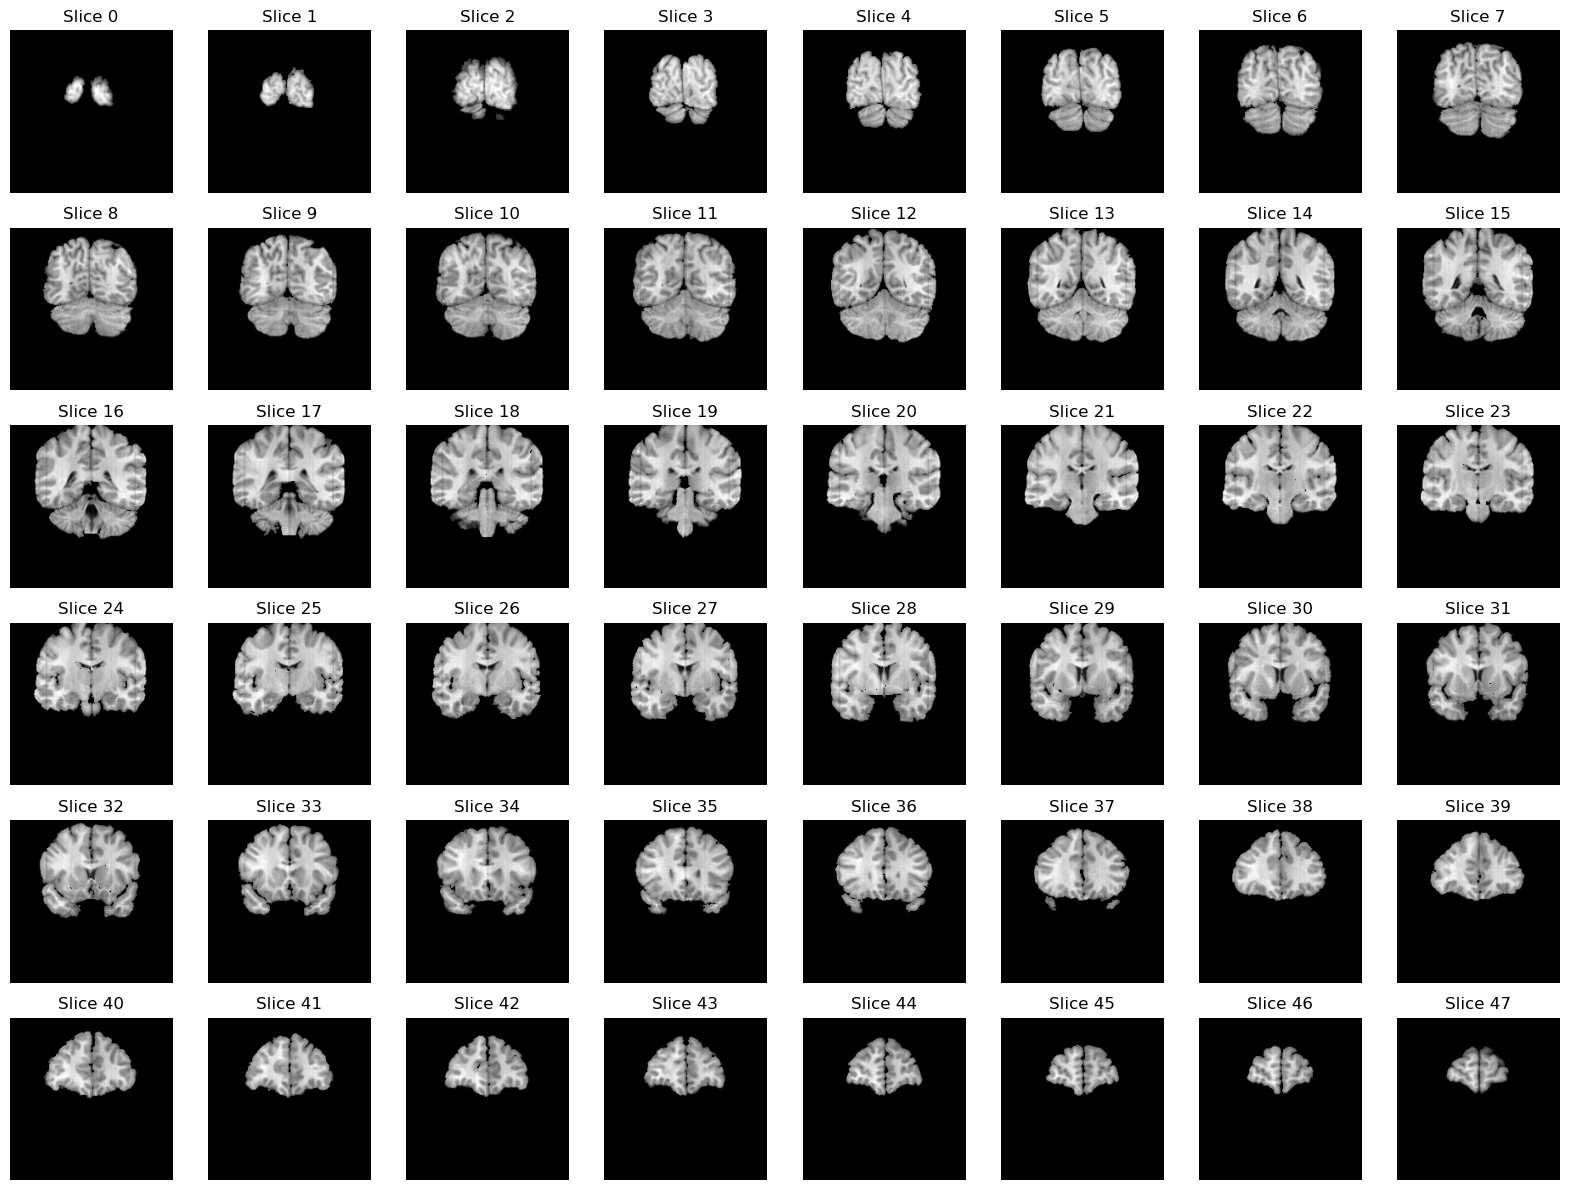

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))
for i in range(48):
    plt.subplot(6, 8, i + 1)
    plt.imshow(patient0_image[i, :, :, 0], cmap="gray")
    plt.title(f"Slice {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

unique labels: [0. 1.]
label count: 2


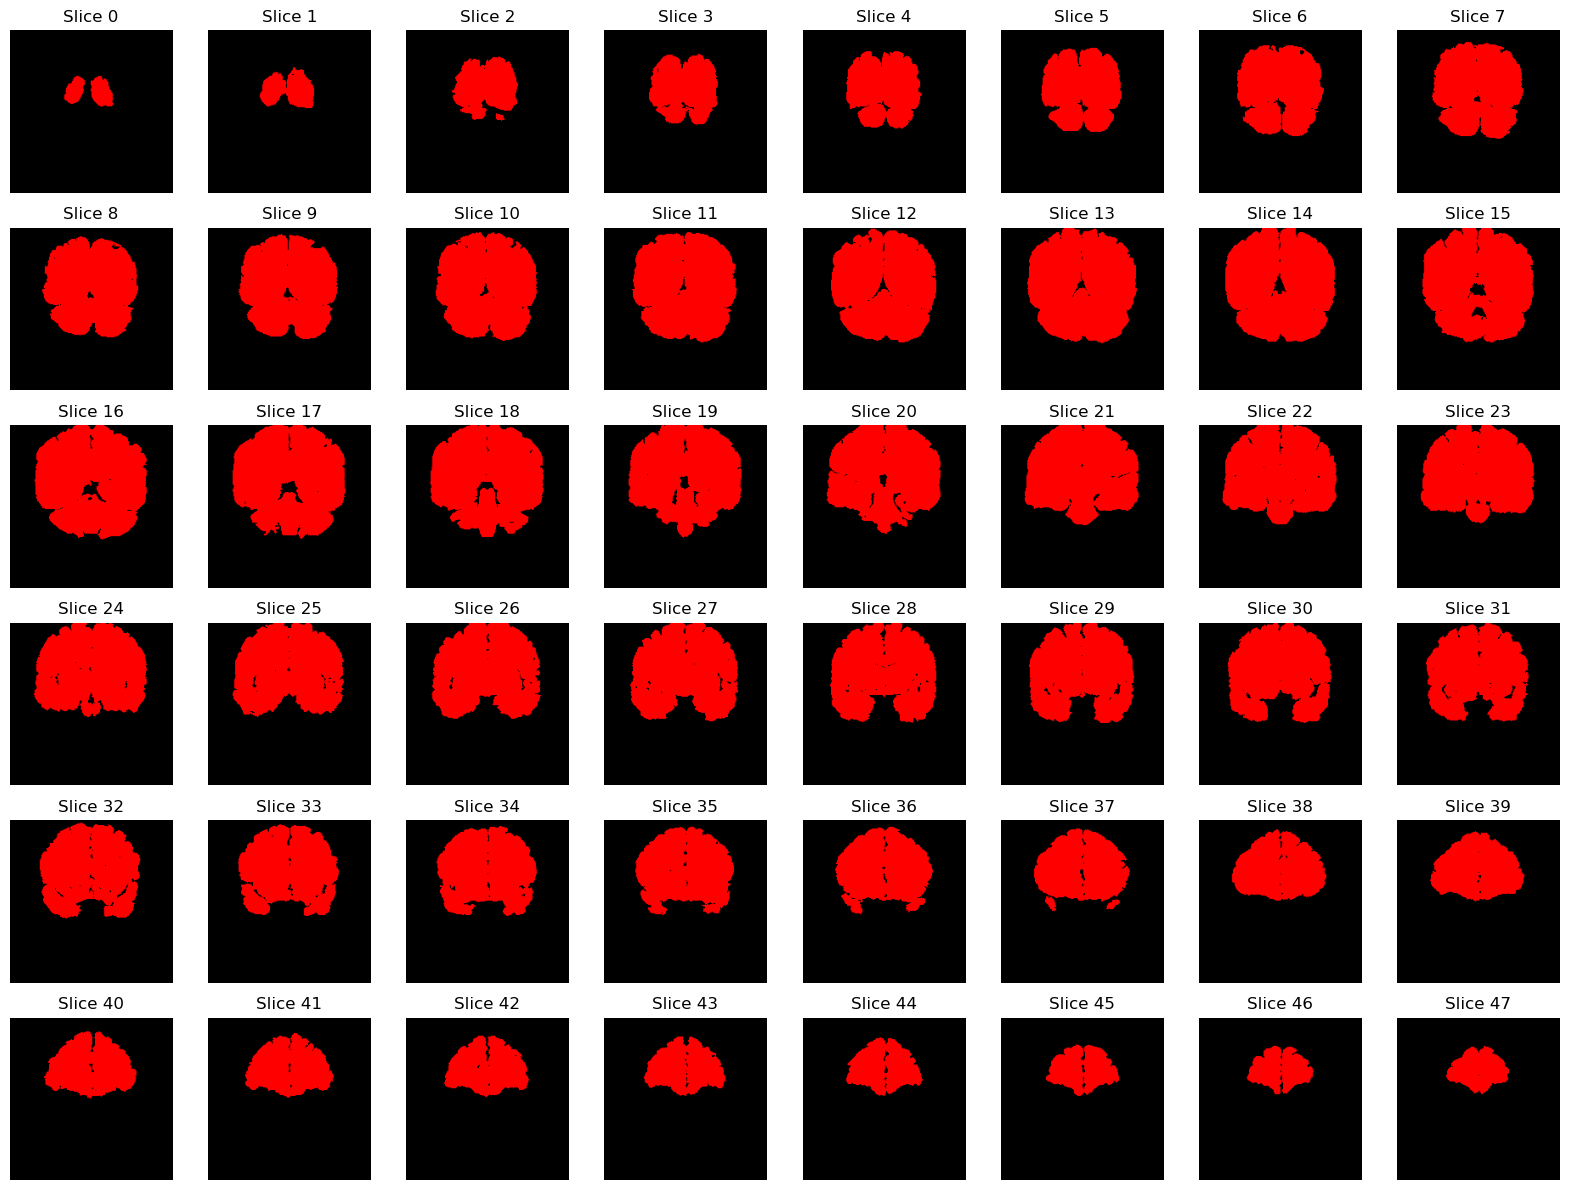

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

patient0_mask_image = np.load("brain tissue segmentation/ibsr_3d/train/mask/mask_0.npy")
colors = [
    [1, 0, 0],        # 0: red
    [0, 0, 0],        # 1: black
    [0.8, 0.4, 0.2],  # 2: orange 
    [0.9, 0.9, 0.9],  # 3: white：
]

cmap = ListedColormap(colors)

print("unique labels:", np.unique(patient0_mask_image))
print("label count:", len(np.unique(patient0_mask_image)))

plt.figure(figsize=(16, 12))
for i in range(48):
    plt.subplot(6, 8, i + 1)
    plt.imshow(patient0_mask_image[i, :, :, 0], cmap=cmap, vmin=0, vmax=3)
    plt.title(f"Slice {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

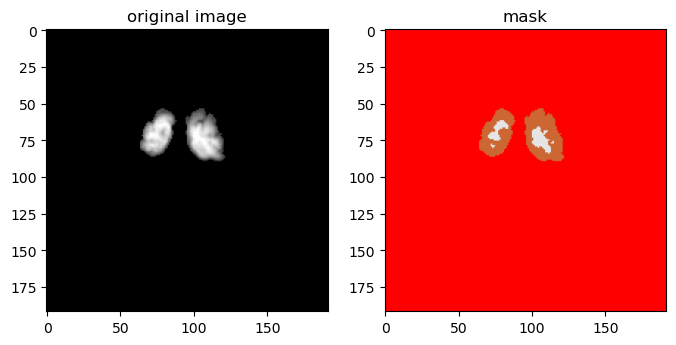

In [ ]:
train_img_dir = "brain tissue segmentation/ibsr_3d/train/images/"
train_mask_dir = "brain tissue segmentation/ibsr_3d/train/mask/"

img = np.load(train_img_dir + "image_0.npy")    # (48, 192, 192, 1)
mask = np.load(train_mask_dir + "mask_0.npy")   # (48, 192, 192, 4)

img_slice = img[0]      # (192, 192, 1)
mask_slice = mask[0]    # (192, 192, 4)

mask_class = np.argmax(mask_slice, axis=-1)   # (192, 192)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_slice, cmap="gray")
axes[0].set_title("original image")
axes[1].imshow(mask_class, cmap=cmap, vmin=0, vmax=3)
axes[1].set_title("mask")
plt.show()

## Import libraries

In [14]:
import numpy as np
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import os
import matplotlib.pyplot as plt
from monai.networks.nets import UNet
from monai.losses import DiceCELoss

In [ ]:
train_img_dir = "brain tissue segmentation/ibsr_3d/train/images/"
train_mask_dir = "brain tissue segmentation/ibsr_3d/train/mask/"
val_img_dir = "brain tissue segmentation/ibsr_3d/valid/images/"
val_mask_dir = "brain tissue segmentation/ibsr_3d/valid/mask/"

import os
print("train dir exist?:", os.path.exists(train_img_dir))
print("train mask dir exist?:", os.path.exists(train_mask_dir))
print("val dir exist?:", os.path.exists(val_img_dir))
print("val mask dir exist?:", os.path.exists(val_mask_dir))


train dir exist?: True
train mask dir exist?: True
val dir exist?: True
val mask dir exist?: True


This class is responsible for reading 3D medical images and masks from disk
and converting them into 2D slice data that can be used by PyTorch.

In [19]:
class IBSR2DDataset(Dataset):
    # img_dir: directory containing training .npy image files
    # mask_dir: directory containing corresponding .npy mask files

    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir

        # get all .npy files and sort them 
        self.img_files = sorted([f for f in os.listdir(img_dir) if f.endswith('.npy')])
        self.mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith('.npy')])

        # for each image file, load it and get the number of slices, then create a list of (image_index, slice_index) tuples
        self.slices = []

        #idx is the position of the file, and s is the slice number within that idx file.
        for idx, img_file in enumerate(self.img_files):
            img = np.load(os.path.join(img_dir, img_file))
            num_slices = img.shape[0]
            for s in range(num_slices):
                self.slices.append((idx, s))
        
        print(f"loaded {len(self.img_files)} files, total {len(self.slices)} slices")

    # return the total num of slices across all the files
    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        file_idx, slice_idx = self.slices[idx]  # get the file index and slice index for this sample
        
        # load the image and mask for the given file index
        img = np.load(os.path.join(self.img_dir, self.img_files[file_idx]))
        mask = np.load(os.path.join(self.mask_dir, self.mask_files[file_idx]))
        
        # get the specific slice for both image and mask
        img_slice = img[slice_idx]      
        mask_slice = mask[slice_idx] 

        # Pytorch can not use (numpy array) directly, we need to covert them to (torch tensor)
        # and also permute the dimensions to [channel, height, width] to [channel, height, width] format for pytorch
        img_tensor = torch.FloatTensor(img_slice).permute(2, 0, 1)   # [C, H, W]
        mask_tensor = torch.FloatTensor(mask_slice).permute(2, 0, 1) # [C, H, W]
        
        # normalize the image tensor to [0, 1]
        img_tensor = img_tensor / 255.0
        
        return img_tensor, mask_tensor  # return both raw image and mask 

## Build dataset and dataloader 

In [22]:
# set the device to mps if available, otherwise use cpu
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"device is: {device}")

# create datasets for training and validation
train_dataset = IBSR2DDataset(train_img_dir, train_mask_dir)
val_dataset = IBSR2DDataset(val_img_dir, val_mask_dir)

# create DataLoader
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

print(f"Training set: {len(train_dataset)} slices")
print(f"Validation set: {len(val_dataset)} slices")

device is: mps
loaded 14 files, total 672 slices
loaded 6 files, total 288 slices
Training set: 672 slices
Validation set: 288 slices


In [24]:
def train_model(train_loader, val_loader, device, epochs=30, lr=1e-4, batch_size=None, accumulation_steps=1):
    """
    Train a U-Net model for 2D image segmentation
    
    Args:
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        device: Device to run training on (cuda/cpu)
        epochs: Number of training epochs
        lr: Learning rate
        batch_size: Optional batch size for logging purposes
        accumulation_steps: Number of steps to accumulate gradients before updating weights
    """
    
    # Build a U-net model for 2D image segmentation
    model = UNet(
        spatial_dims=2, # 2D U-Net
        in_channels=1,  # input channel is 1 for grayscale images
        out_channels=4, # output channel is 4 for 4 classes 
        channels=(64, 128, 256, 512), # The number of feature maps in each layer
        strides=(2, 2, 2), # The stride for downsampling in each layer
        num_res_units = 2,   # The number of residual units in each layer
    ).to(device)

    loss_fn = DiceCELoss(to_onehot_y=True, softmax=True)

    """
    DiceCELoss logic
    class DiceCELoss:
        def forward(self, outputs, masks):
            # 1. calculate the loss for each sample in the batch
            per_sample_losses = []
            for i in range(outputs.shape[0]):  # batch size
                loss_i = compute_dice_ce(outputs[i], masks[i])
                per_sample_losses.append(loss_i)
            
            # 2. by default, the loss is averaged over the batch dimension.
            return torch.mean(torch.stack(per_sample_losses))
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []

    # Training loop
    for epoch in range(epochs):
        model.train()   # Change model to training mode
        train_loss = 0  # Sum up the losses of each batch
        optimizer.zero_grad()  # Zero gradients at the start of each epoch
        
        for batch_idx, (imgs, masks) in enumerate(train_loader):

            # Transfer the data to the device (GPU or CPU)
            imgs = imgs.to(device)
            masks = masks.to(device)

            # Forward propagation
            outputs = model(imgs)

            # Calculate the loss
            # Add channel dimension to masks_class to match expected shape
            masks_class = torch.argmax(masks, dim=1, keepdim=True)  # (B, 1, 192, 192) instead of (B, 192, 192)
            loss = loss_fn(outputs, masks_class)
            
            # Normalize loss to account for gradient accumulation
            loss = loss / accumulation_steps

            # Backpropagation
            loss.backward()

            # Update weights after accumulating gradients for specified steps
            if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(train_loader):
                # Update the model parameters based on the gradients
                optimizer.step()
                optimizer.zero_grad()  # Reset gradients after update

            # Add the loss of this batch to the total training loss
            train_loss += loss.item() * accumulation_steps  # Multiply back to get actual loss

        # Calculate the average training loss for this epoch and append it to the list of training losses
        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs = imgs.to(device)
                masks = masks.to(device)
                outputs = model(imgs)
                # Add channel dimension to masks_class to match expected shape
                masks_class = torch.argmax(masks, dim=1, keepdim=True)  # (B, 1, 192, 192) instead of (B, 192, 192)
                loss = loss_fn(outputs, masks_class)
                val_loss += loss.item()

        """
        The loss of each batch is already the average value of all samples within that batch. 
        We just need to add up all the batch losses
        and then divide by the total number of batches to obtain the average loss for the entire epoch.
        """
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        scheduler.step(avg_val_loss)
        
        # Keep the best model based on validation loss
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_unet_model.pth')
            print(f"Epoch {epoch+1}: Updated best model (val_loss={avg_val_loss:.4f})")
        
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
            if batch_size:
                print(f"Effective batch size: {batch_size * accumulation_steps}")
    
    return model, train_losses, val_losses

In [26]:
# start training the model
print("Starting training")
model, train_losses, val_losses = train_model(
    train_loader, 
    val_loader, 
    device, 
    epochs=20, 
    lr=1e-4)
print("Training completed \n The model has been saved as best_unet_model.pth")

Starting training
Epoch 1: Updated best model (val_loss=1.4102)
Epoch 2: Updated best model (val_loss=1.2775)
Epoch 3: Updated best model (val_loss=1.1723)
Epoch 4: Updated best model (val_loss=1.0839)
Epoch 5: Updated best model (val_loss=1.0131)
Epoch 6: Updated best model (val_loss=0.9402)
Epoch 7: Updated best model (val_loss=0.8790)
Epoch 8: Updated best model (val_loss=0.8267)
Epoch 9: Updated best model (val_loss=0.7783)
Epoch 10: Updated best model (val_loss=0.7367)
Epoch 10/20 | Train Loss: 0.7600 | Val Loss: 0.7367
Epoch 11: Updated best model (val_loss=0.6996)
Epoch 12: Updated best model (val_loss=0.6671)
Epoch 13: Updated best model (val_loss=0.6348)
Epoch 14: Updated best model (val_loss=0.6075)
Epoch 15: Updated best model (val_loss=0.5866)
Epoch 16: Updated best model (val_loss=0.5659)
Epoch 17: Updated best model (val_loss=0.5451)
Epoch 18: Updated best model (val_loss=0.5292)
Epoch 19: Updated best model (val_loss=0.5104)
Epoch 20: Updated best model (val_loss=0.4971)

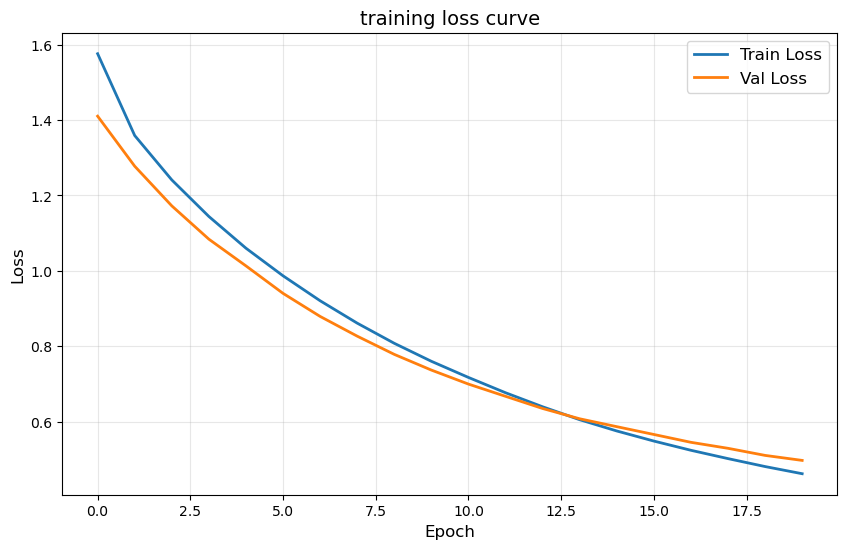

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.title('training loss curve', fontsize=14)
plt.show()

In [30]:
import torch
import numpy as np
import os
from monai.networks.nets import UNet

# 1. Load model
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = UNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=4,
    channels=(64, 128, 256, 512),
    strides=(2, 2, 2),
    num_res_units=2,
).to(device)

model.load_state_dict(torch.load('best_unet_model.pth', map_location=device))
model.eval()
print("Model loaded successfully!")

# 2. Validation paths
val_img_dir = "/Users/jeffreytian/Desktop/brain tissue segmentation/ibsr_3d/valid/images/"
val_mask_dir = "/Users/jeffreytian/Desktop/brain tissue segmentation/ibsr_3d/valid/mask/"

img_files = sorted([f for f in os.listdir(val_img_dir) if f.endswith('.npy')])
mask_files = sorted([f for f in os.listdir(val_mask_dir) if f.endswith('.npy')])

# 3. Initialize statistics
total_dice = np.zeros(4)
total_iou = np.zeros(4)
total_acc = 0
total_slices = 0

# 4. Iterate over all validation slices
for file_idx, (img_file, mask_file) in enumerate(zip(img_files, mask_files)):
    img = np.load(os.path.join(val_img_dir, img_file))
    mask = np.load(os.path.join(val_mask_dir, mask_file))
    
    for slice_idx in range(img.shape[0]):
        img_slice = img[slice_idx]
        mask_slice = mask[slice_idx]
        mask_class = np.argmax(mask_slice, axis=-1)
        
        # Predict
        img_tensor = torch.FloatTensor(img_slice).permute(2, 0, 1).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(img_tensor)
            pred_class = torch.argmax(pred, dim=1).squeeze().cpu().numpy()
        
        # Compute Dice and IoU for each class
        for c in range(4):
            pred_binary = (pred_class == c)
            true_binary = (mask_class == c)
            intersection = np.logical_and(pred_binary, true_binary).sum()
            union = np.logical_or(pred_binary, true_binary).sum()
            
            # Dice
            if union == 0:
                total_dice[c] += 1.0
            else:
                total_dice[c] += (2.0 * intersection) / (pred_binary.sum() + true_binary.sum())
            
            # IoU
            if union == 0:
                total_iou[c] += 1.0
            else:
                total_iou[c] += intersection / union
        
        # Pixel accuracy
        correct = (pred_class == mask_class).sum()
        total = mask_class.size
        total_acc += correct / total
        total_slices += 1

# 5. Compute final metrics
avg_dice = total_dice / total_slices
avg_iou = total_iou / total_slices
overall_acc = total_acc / total_slices
mean_dice = np.mean(avg_dice)
mean_iou = np.mean(avg_iou)

# 6. Print results
print("VALIDATION RESULTS")
print(f"Total slices: {total_slices}")
print(f"Overall Pixel Accuracy : {overall_acc:.4f}")
print(f"Mean Dice (4 classes)  : {mean_dice:.4f}")
print(f"Mean IoU  (4 classes)  : {mean_iou:.4f}")
print("Class | Dice    | IoU")
for c in range(4):
    print(f"  {c}   | {avg_dice[c]:.4f}  | {avg_iou[c]:.4f}")


Model loaded successfully!
VALIDATION RESULTS
Total slices: 288
Overall Pixel Accuracy : 0.9452
Mean Dice (4 classes)  : 0.6634
Mean IoU  (4 classes)  : 0.5761
Class | Dice    | IoU
  0   | 0.9957  | 0.9914
  1   | 0.1735  | 0.1249
  2   | 0.7771  | 0.6382
  3   | 0.7074  | 0.5499
